# 🩺 Pima Indians Diabetes Dataset — EDA Practical
**Problem Statement:**  
Diabetes is one of the most prevalent chronic diseases worldwide. In this exercise, you will explore the Pima Indians Diabetes dataset containing medical measurements such as glucose, blood pressure, BMI, insulin, age, and whether the patient has diabetes or not. Your goal is to perform Exploratory Data Analysis (EDA) to uncover patterns and insights that might explain which factors influence the onset of diabetes.

**Learning Objectives:**
- Load and inspect a real-world medical dataset
- Understand dataset structure and summary statistics
- Calculate central tendency measures: mean, median, mode
- Identify and handle missing data (including hidden zeros)
- Perform univariate and bivariate analysis using plots
- Explore correlations between numerical variables
- Gain hands-on experience with pandas and seaborn libraries

**Tasks to be completed step-by-step:**
- Step 1: Import necessary libraries
- Step 2: Load the Diabetes dataset and preview it
- Step 3: Check dataset shape, data types, and missing values
- Step 4: Calculate descriptive statistics and central tendency (mean, median, mode)
- Step 5: Visualize distributions and key statistics
- Step 6: Analyze missing data and discuss its impact
- Step 7: Perform univariate analysis of individual features
- Step 8: Perform bivariate analysis to study relationships between features
- Step 9: Compute and visualize the correlation matrix for numeric features
- Step 10: Summarize findings and prepare for further modeling or data cleaning


## Step 1: Import Libraries
> **Why for Diabetes dataset?**  
> We need `pandas` to load and manipulate the tabular medical data, `numpy` for numerical operations like replacing zeros with NaN, `matplotlib` and `seaborn` for all visualizations. These are the standard tools for any EDA task.


In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Diabetes Dataset and Preview It
> **Why for Diabetes dataset?**  
> We load the CSV file and call `df.head()` to get a first look at the data — what columns exist, what values look like, and whether anything looks suspicious at first glance.  
> Unlike the Titanic dataset which is built into seaborn, the Diabetes dataset is loaded from a CSV file.


In [2]:
# Step 2: Load Dataset
df = pd.read_csv('diabetes_dirty_dataset.csv')

print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,PatientID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cholesterol,SodiumLevel,HeartRate,VitaminD,ExerciseHrsPerWeek,Outcome
0,P0529,2,120,82,40.0,51.0,35.2,1.105,37.0,168,140.0,84,17.8,6.5,0
1,P0283,8,121,107,34.0,182.0,36.2,0.338,53.0,220,138.3,84,48.5,1.2,1
2,P0844,12,177,100,53.0,376.0,42.8,2.195,37.0,218,141.3,85,46.9,NaN,1
3,P0121,2,115,0,NaN,52.0,27.3,1.015,37.0,155,143.5,90,27.7,6.3,0
4,P0001,2,129,80,18.0,101.0,24.0,0.691,21.0,212,136.8,73,53.0,6.8,0


## Step 3: Check Dataset Shape, Data Types, and Missing Values
> **Why for Diabetes dataset?**  
> - `df.shape` tells us we have 768 patients and 9 columns (8 features + 1 target)  
> - `df.info()` confirms all columns are numeric (int64/float64) — no string columns unlike Titanic  
> - `df.isnull().sum()` will show 0 missing values — BUT this is misleading! The real missing values are disguised as 0s in medical columns. We will handle this in Step 6.


In [3]:
# Step 3: Dataset Shape and Info
print(f"Dataset shape (rows, columns): {df.shape}\n")
print(df.info())

Dataset shape (rows, columns): (1015, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 1015 non-null   object 
 1   Pregnancies               1015 non-null   int64  
 2   Glucose                   935 non-null    object 
 3   BloodPressure             1015 non-null   int64  
 4   SkinThickness             935 non-null    float64
 5   Insulin                   937 non-null    float64
 6   BMI                       1015 non-null   float64
 7   DiabetesPedigreeFunction  1015 non-null   float64
 8   Age                       1015 non-null   float64
 9   Cholesterol               1015 non-null   int64  
 10  SodiumLevel               1015 non-null   float64
 11  HeartRate                 1015 non-null   int64  
 12  VitaminD                  934 non-null    float64
 13  ExerciseHrsPerWeek  

In [4]:
# Check missing values at first glance
print("Missing value count per column:")
print(df.isnull().sum())
print("\n⚠️  All show 0 — but zeros in medical columns are actually missing values!")

Missing value count per column:
PatientID                    0
Pregnancies                  0
Glucose                     80
BloodPressure                0
SkinThickness               80
Insulin                     78
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                      0
dtype: int64

⚠️  All show 0 — but zeros in medical columns are actually missing values!


## Step 4: Calculate Descriptive Statistics and Central Tendency (Mean, Median, Mode)
> **Why for Diabetes dataset?**  
> - `df.describe()` gives us count, mean, std, min, max and quartiles for all 8 features  
> - **Key red flag to spot:** Glucose, BloodPressure, SkinThickness, Insulin, BMI all show **min = 0** — which is biologically impossible. This is our first signal that zeros = missing data  
> - Mean, Median, Mode for Glucose specifically helps understand its distribution and skew before we do any cleaning


In [5]:
# Step 4: Summary Statistics
print("Descriptive Statistics:")
df.describe().T

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,1015.0,3.953695,3.021753,-7.00,2.000,3.000,6.000,12.000
BloodPressure,1015.0,77.821675,25.586700,0.00,65.000,76.000,87.000,300.000
SkinThickness,935.0,28.067380,12.381894,-43.00,20.000,28.000,37.000,54.000
Insulin,937.0,247.248666,965.699749,-10.00,85.000,136.000,196.000,9999.000
BMI,1015.0,32.257143,11.635791,-3.00,25.450,31.100,36.850,120.500
DiabetesPedigreeFunction,1015.0,0.886528,0.565512,0.08,0.441,0.793,1.146,2.413
Age,1015.0,41.093005,19.757258,-1.00,29.000,38.000,51.000,200.000
Cholesterol,1015.0,200.347783,29.370453,150.00,176.000,202.000,226.000,250.000
SodiumLevel,1015.0,139.683547,2.948790,135.00,137.100,139.400,142.200,145.000
HeartRate,1015.0,78.359606,19.932078,-99.00,69.000,80.000,90.000,100.000


In [6]:
junk = ["O","l","?","#"]
for ch in junk:
    df["Glucose"] = df["Glucose"].str.replace(ch, "", regex=False)
df["Glucose"] = df["Glucose"].apply(lambda x:float(x))
df.dtypes

PatientID                    object
Pregnancies                   int64
Glucose                     float64
BloodPressure                 int64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Cholesterol                   int64
SodiumLevel                 float64
HeartRate                     int64
VitaminD                    float64
ExerciseHrsPerWeek          float64
Outcome                      object
dtype: object

In [7]:
# Central tendency for Glucose (most important feature for diabetes)
mean_glucose   = df['Glucose'].mean()
median_glucose = df['Glucose'].median()
mode_glucose   = df['Glucose'].mode()[0]

print(f"Glucose — Mean  : {mean_glucose:.2f}")
print(f"Glucose — Median: {median_glucose:.2f}")
print(f"Glucose — Mode  : {mode_glucose}")

# Central tendency for Age
mean_age   = df['Age'].mean()
median_age = df['Age'].median()
mode_age   = df['Age'].mode()[0]

print(f"\nAge — Mean  : {mean_age:.2f}")
print(f"Age — Median: {median_age:.2f}")
print(f"Age — Mode  : {mode_age}")

# Mode for target (Outcome)
mode_outcome = df['Outcome'].mode()[0]
print(f"\nOutcome — Mode (most common class): {mode_outcome}  (0=Non-Diabetic)")

Glucose — Mean  : 125.01
Glucose — Median: 122.00
Glucose — Mode  : 139.0

Age — Mean  : 41.09
Age — Median: 38.00
Age — Mode  : 23.0

Outcome — Mode (most common class): 0  (0=Non-Diabetic)


## Step 5: Visualize Distributions and Key Statistics
> **Why for Diabetes dataset?**  
> We plot the Glucose distribution with Mean, Median, and Mode marked as vertical lines.  
> - If Mean > Median → data is **right-skewed** (pulled by high glucose outliers)  
> - Glucose is the single most important predictor of diabetes — understanding its shape matters  
> - The spike at 0 (before cleaning) would be visible here, confirming the zero-as-missing problem


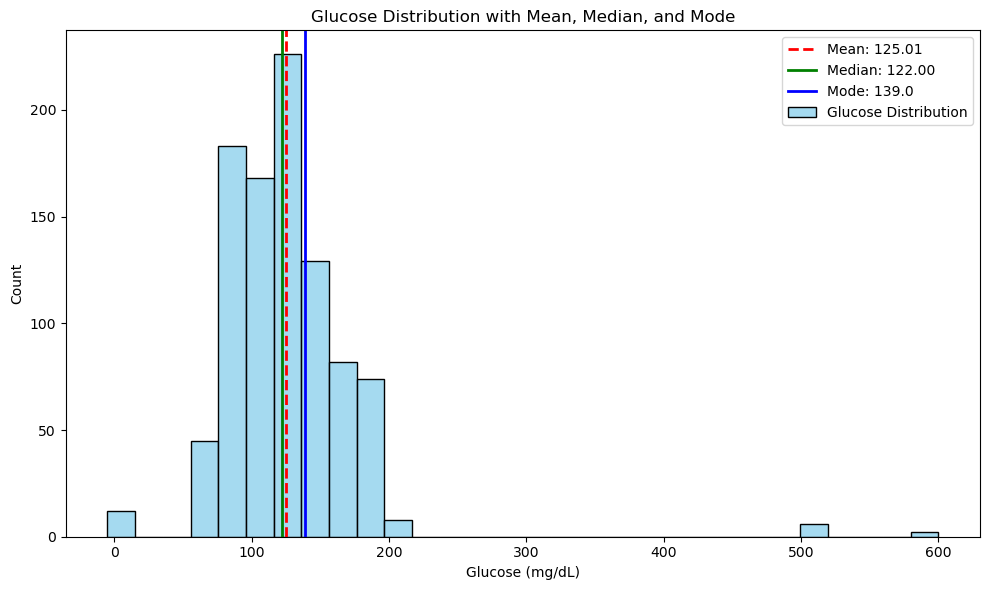

In [8]:
# Step 5: Visualize Glucose Distribution with Mean, Median, Mode
plt.figure(figsize=(10, 6))
sns.histplot(df['Glucose'], bins=30, kde=False, color='skyblue', label='Glucose Distribution')
plt.axvline(mean_glucose,   color='red',   linestyle='--', linewidth=2, label=f'Mean: {mean_glucose:.2f}')
plt.axvline(median_glucose, color='green', linestyle='-',  linewidth=2, label=f'Median: {median_glucose:.2f}')
plt.axvline(mode_glucose,   color='blue',  linestyle='-',  linewidth=2, label=f'Mode: {mode_glucose}')
plt.title('Glucose Distribution with Mean, Median, and Mode')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

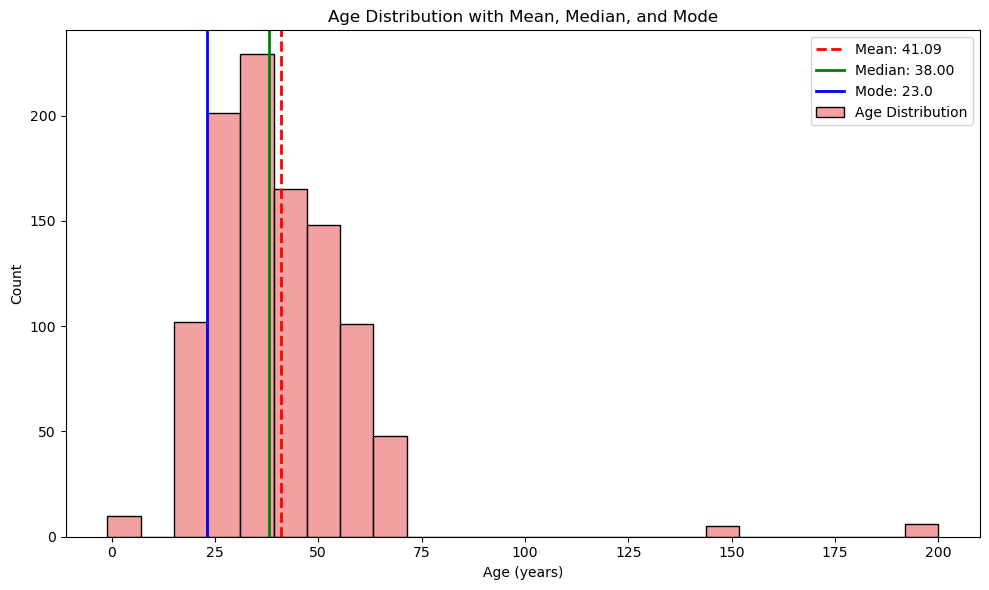

In [9]:
# Visualize Age Distribution with Mean, Median, Mode
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=25, kde=False, color='lightcoral', label='Age Distribution')
plt.axvline(mean_age,   color='red',   linestyle='--', linewidth=2, label=f'Mean: {mean_age:.2f}')
plt.axvline(median_age, color='green', linestyle='-',  linewidth=2, label=f'Median: {median_age:.2f}')
plt.axvline(mode_age,   color='blue',  linestyle='-',  linewidth=2, label=f'Mode: {mode_age}')
plt.title('Age Distribution with Mean, Median, and Mode')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Step 6: Analyze Missing Data and Discuss Its Impact
> **Why for Diabetes dataset?**  
> This step is **unique and critical** for the Diabetes dataset.  
> Unlike Titanic where missing values show up as NaN directly, here missing values are **disguised as 0**.  
> Medically, a patient cannot have:
> - Glucose = 0 (would be dead)
> - BloodPressure = 0 (would be dead)
> - BMI = 0 (impossible)
> - SkinThickness = 0 (impossible to measure)
> - Insulin = 0 (very unlikely — would be recorded)
>
> We first count and visualize these zeros, then **replace them with NaN** so they can be properly handled.  
> Note: `Pregnancies = 0` IS valid (never been pregnant) and `Outcome = 0/1` is the target, so we don't touch those.


In [10]:
# Step 6a: Count zeros in columns where 0 is medically impossible
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts in medically impossible columns (= hidden missing values):")
print("-" * 55)
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct   = zeros / len(df) * 100
    print(f"  {col:<20}: {zeros:>3} zeros  ({pct:.1f}%)")

Zero counts in medically impossible columns (= hidden missing values):
-------------------------------------------------------
  Glucose             :   5 zeros  (0.5%)
  BloodPressure       :  10 zeros  (1.0%)
  SkinThickness       :   0 zeros  (0.0%)
  Insulin             :   7 zeros  (0.7%)
  BMI                 :   4 zeros  (0.4%)


In [11]:
# Step 6b: Replace 0 with NaN in those columns
df[zero_cols] = df[zero_cols].replace(0, np.nan)

print("Missing values AFTER 0 → NaN replacement:")
print(df.isnull().sum())

Missing values AFTER 0 → NaN replacement:
PatientID                    0
Pregnancies                  0
Glucose                     85
BloodPressure               10
SkinThickness               80
Insulin                     85
BMI                          4
DiabetesPedigreeFunction     0
Age                          0
Cholesterol                  0
SodiumLevel                  0
HeartRate                    0
VitaminD                    81
ExerciseHrsPerWeek          82
Outcome                      0
dtype: int64


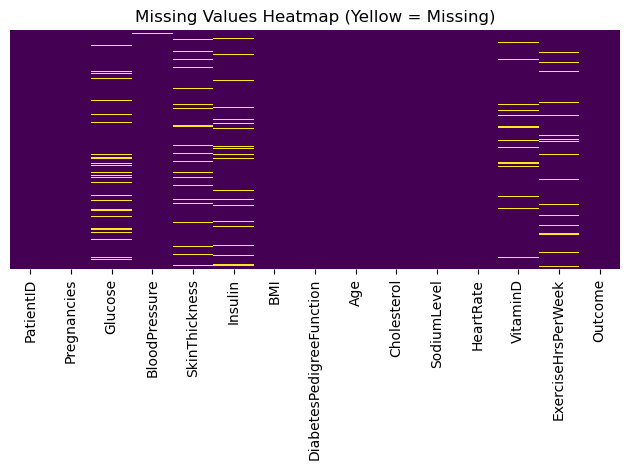

In [12]:
# Step 6c: Visualize missing data with heatmap
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

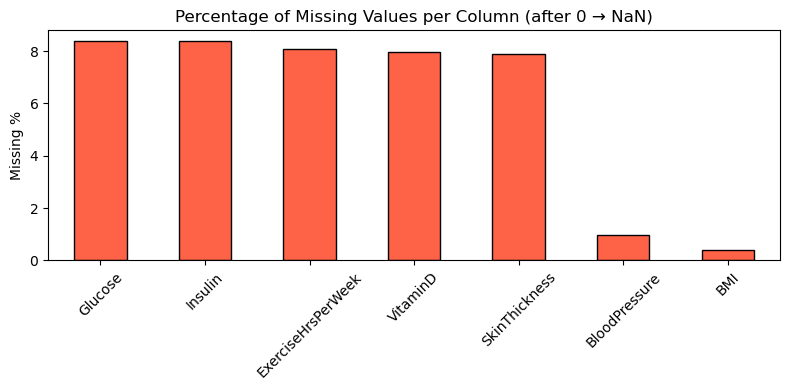


💡 Insulin has ~49% missing — use median imputation (robust to skew)
💡 SkinThickness has ~30% missing — use median imputation
💡 Glucose/BP/BMI have <5% missing — use mean imputation


In [13]:
# Step 6d: Bar chart of missing percentage per column
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct.plot(kind='bar', color='tomato', edgecolor='black', figsize=(8, 4))
plt.title('Percentage of Missing Values per Column (after 0 → NaN)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n💡 Insulin has ~49% missing — use median imputation (robust to skew)")
print("💡 SkinThickness has ~30% missing — use median imputation")
print("💡 Glucose/BP/BMI have <5% missing — use mean imputation")

In [19]:
# Step 6e: Impute missing values
# Median for heavily skewed columns
for col in ['Insulin', 'SkinThickness']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"{col:<20}: filled with median = {median_val}")

# Mean for roughly normal columns
for col in ['Glucose', 'BloodPressure', 'BMI']:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)
    print(f"{col:<20}: filled with mean   = {mean_val:.2f}")

print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")

Insulin             : filled with median = 138.0
SkinThickness       : filled with median = 28.0
Glucose             : filled with mean   = 125.69
BloodPressure       : filled with mean   = 78.60
BMI                 : filled with mean   = 32.38

Total missing values remaining: 163


## Step 7: Perform Univariate Analysis of Individual Features
> **Why for Diabetes dataset?**  
> We study each column independently to understand its own distribution.  
> - **Outcome (target):** Countplot shows class imbalance — ~65% non-diabetic, ~35% diabetic. This matters when choosing evaluation metrics (accuracy alone is not enough!)  
> - **Passenger class in Titanic = Pregnancies in Diabetes:** Shows most patients had 0–3 pregnancies  
> - **Age:** Right-skewed — most patients are young adults (21–40 range)  
> - **Glucose:** Nearly normal after imputation — good for linear models  
> - Histograms with KDE overlay show shape, skew, and potential outliers for all 8 features


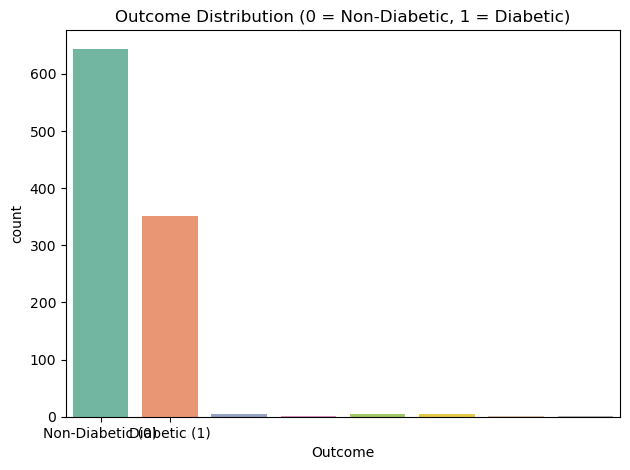

Outcome
0        644
1        351
Yes        5
0.0        5
No         5
1.0        2
FALSE      2
TRUE       1
Name: count, dtype: int64

Class imbalance ratio: 644 Non-Diabetic : 351 Diabetic


In [20]:
# Step 7a: Survival Count → Outcome (Diabetic vs Non-Diabetic) Distribution
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Outcome Distribution (0 = Non-Diabetic, 1 = Diabetic)')
plt.xlabel('Outcome')
plt.xticks([0, 1], ['Non-Diabetic (0)', 'Diabetic (1)'])
plt.tight_layout()
plt.show()

print(df['Outcome'].value_counts())
print(f"\nClass imbalance ratio: {df['Outcome'].value_counts()[0]} Non-Diabetic : {df['Outcome'].value_counts()[1]} Diabetic")

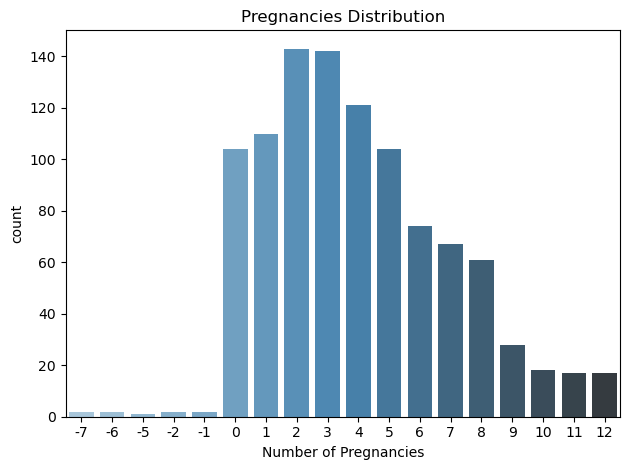

In [14]:
# Step 7b: Pregnancies distribution (like Pclass in Titanic — a discrete count)
sns.countplot(x='Pregnancies', data=df, palette='Blues_d')
plt.title('Pregnancies Distribution')
plt.xlabel('Number of Pregnancies')
plt.tight_layout()
plt.show()

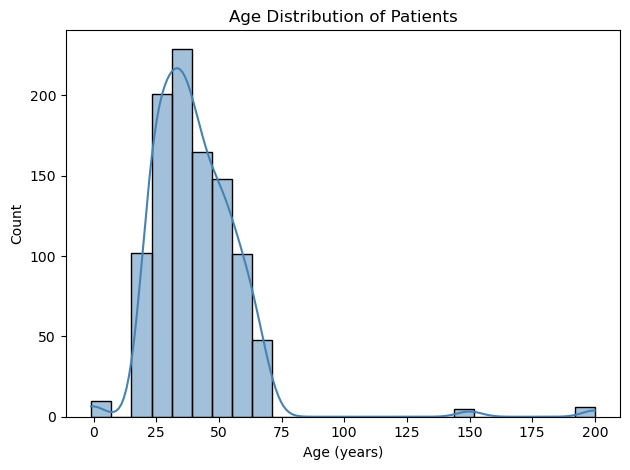

In [15]:
# Step 7c: Age distribution with KDE (like Titanic age analysis)
sns.histplot(df['Age'], kde=True, color='steelblue', bins=25)
plt.title('Age Distribution of Patients')
plt.xlabel('Age (years)')
plt.tight_layout()
plt.show()

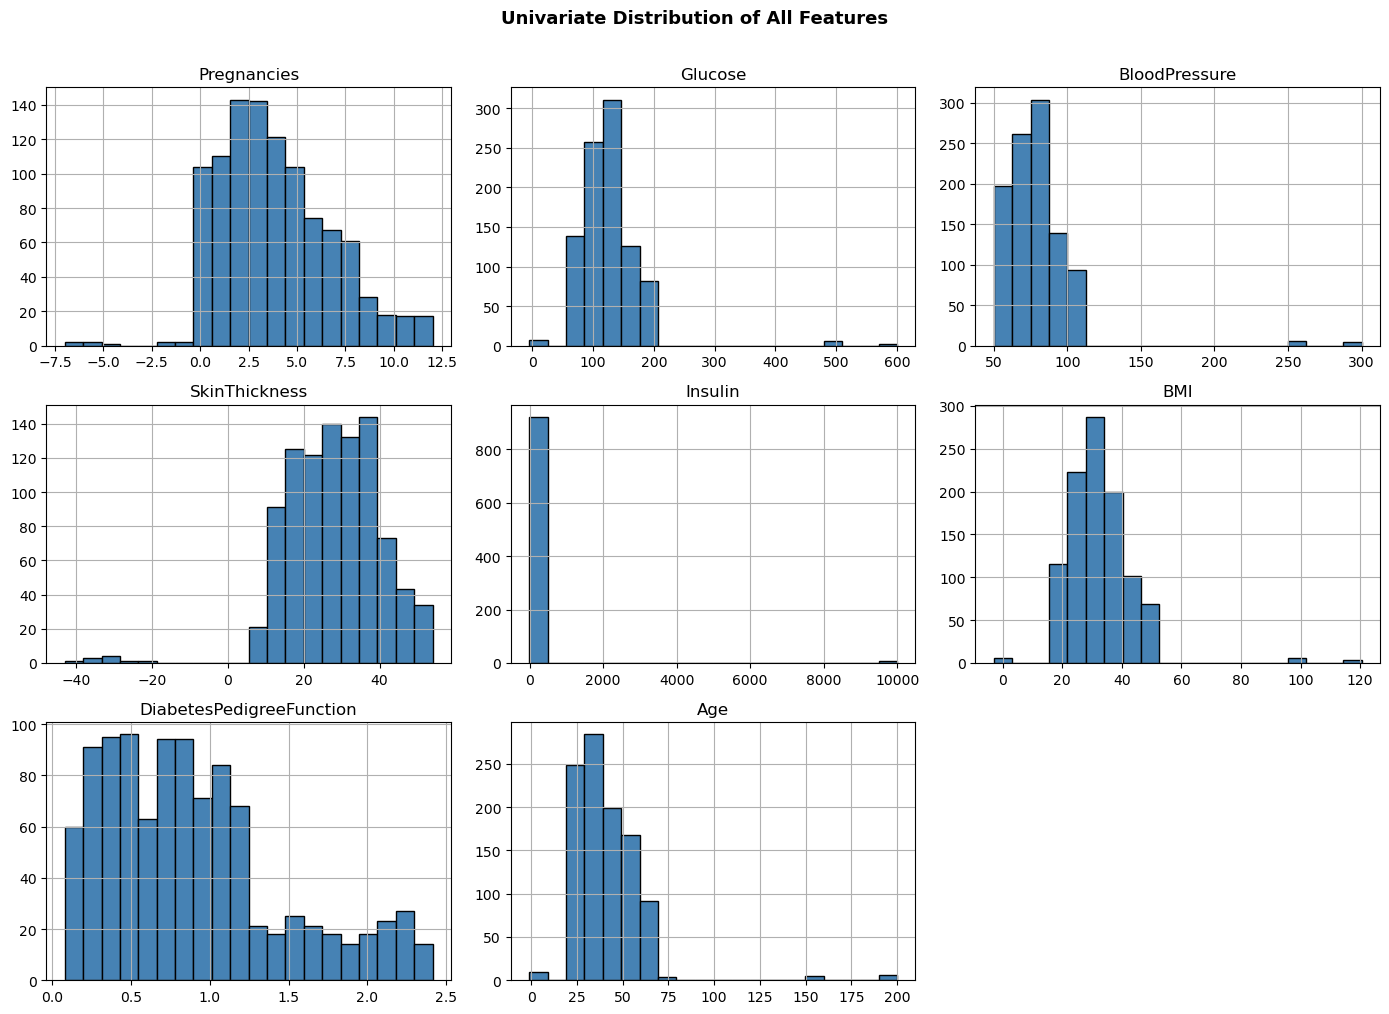

In [16]:
# Step 7d: All features — histogram grid
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

df[features].hist(figsize=(14, 10), bins=20, edgecolor='black', color='steelblue')
plt.suptitle('Univariate Distribution of All Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 8: Perform Bivariate Analysis to Study Relationships Between Features
> **Why for Diabetes dataset?**  
> Now we study how each feature relates to the **Outcome (diabetic or not)** — similar to how Titanic bivariate analysis compared features against survival.  
> - **Survival by gender in Titanic → Outcome by Glucose in Diabetes:** Does glucose level separate diabetics from non-diabetics?  
> - **Age vs Survival boxplot in Titanic → Age vs Outcome boxplot in Diabetes:** Are diabetics typically older?  
> - **Fare vs Survival in Titanic → BMI vs Outcome in Diabetes:** Is higher BMI linked to diabetes?  
> - KDE plots show where the two class distributions overlap or separate cleanly


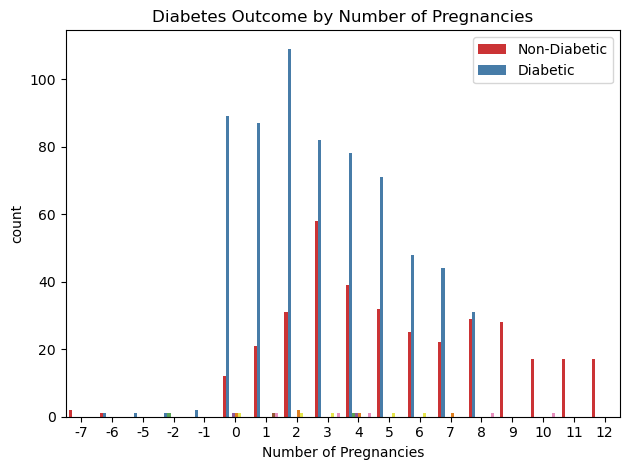

In [17]:
# Step 8a: Survival by Gender in Titanic → Outcome by Pregnancies count in Diabetes
# (Are patients with more pregnancies more likely to be diabetic?)
sns.countplot(x='Pregnancies', hue='Outcome', data=df, palette='Set1')
plt.title('Diabetes Outcome by Number of Pregnancies')
plt.xlabel('Number of Pregnancies')
plt.legend(['Non-Diabetic', 'Diabetic'])
plt.tight_layout()
plt.show()

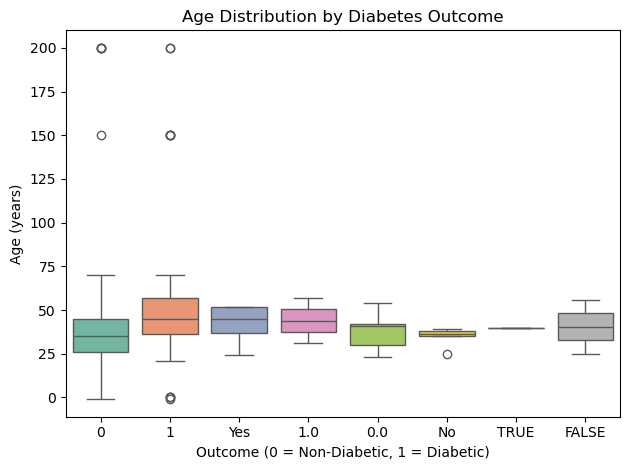

Non-Diabetic mean age: nan


AttributeError: 'float' object has no attribute 'round'

In [20]:
# Step 8b: Age distribution by Outcome (same as Titanic's age vs survived boxplot)
sns.boxplot(x='Outcome', y='Age', data=df, palette='Set2')
plt.title('Age Distribution by Diabetes Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Age (years)')
plt.tight_layout()
plt.show()

print("Non-Diabetic mean age:", round(df[df['Outcome']==0]['Age'].mean(),2))
print("Diabetic mean age    :", df[df['Outcome']==1]['Age'].mean().round(2))

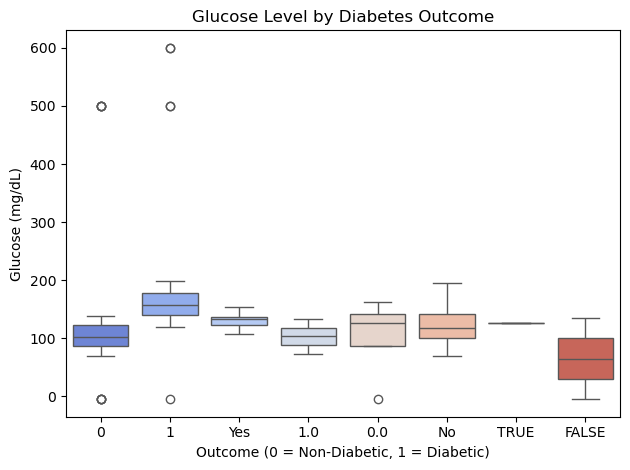

AttributeError: 'float' object has no attribute 'round'

In [21]:
# Step 8c: Fare vs Survival in Titanic → Glucose vs Outcome in Diabetes
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='coolwarm')
plt.title('Glucose Level by Diabetes Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Glucose (mg/dL)')
plt.tight_layout()
plt.show()

print("Non-Diabetic mean Glucose:", df[df['Outcome']==0]['Glucose'].mean().round(1))
print("Diabetic mean Glucose    :", df[df['Outcome']==1]['Glucose'].mean().round(1))

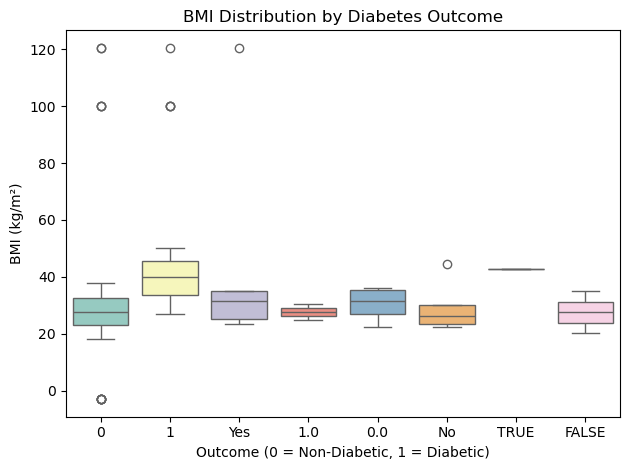

In [22]:
# Step 8d: BMI vs Outcome (additional — BMI is a key diabetes risk factor)
sns.boxplot(x='Outcome', y='BMI', data=df, palette='Set3')
plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('BMI (kg/m²)')
plt.tight_layout()
plt.show()

In [ ]:
# Step 8e: KDE plots — feature distribution by Outcome class (all 8 features)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    df.groupby('Outcome')[col].plot(kind='kde', ax=axes[i], legend=True)
    axes[i].set_title(col)
    axes[i].legend(['Non-Diabetic (0)', 'Diabetic (1)'])
plt.suptitle('Feature Distribution by Outcome — KDE (Bivariate)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Compute and Visualize the Correlation Matrix for Numeric Features
> **Why for Diabetes dataset?**  
> - All 9 columns in the Diabetes dataset are numeric, so the full correlation matrix can be computed directly — unlike Titanic where string columns (sex, embarked) had to be excluded using `select_dtypes`  
> - `df.corr()` computes Pearson correlation (r) between every pair of columns  
> - The heatmap with `annot=True` shows the actual r values in each cell  
> - **Key finding to observe:** Glucose has the highest positive correlation with Outcome (~0.49), followed by BMI and Age — this tells us which features will be most useful for a classification model  
> - We also plot feature correlations with Outcome as a separate bar chart for clarity


In [ ]:
# Step 9a: Full Correlation Matrix (all features are numeric — no select_dtypes needed)
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — All Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
# Step 9b: Feature correlation with Outcome only (bar chart — clearer view)
target_corr = corr['Outcome'].drop('Outcome').sort_values(ascending=False)
print("Feature correlation with Outcome (target):")
print(target_corr.round(3).to_string())

plt.figure(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Feature Correlation with Outcome (Diabetic or Not)')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Pearson r')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n💡 Glucose is the strongest predictor of diabetes (highest r with Outcome)")

## Step 10: Summarize Findings and Prepare for Further Modeling or Data Cleaning

### Key Findings from EDA

| Finding | Detail |
|---|---|
| **Dataset size** | 768 patients, 8 features, 1 target (Outcome) |
| **All features are numeric** | No encoding needed (unlike Titanic's sex/embarked) |
| **Class imbalance** | 65% Non-Diabetic (0), 35% Diabetic (1) — use stratified split |
| **Hidden missing values** | Zeros in Glucose, BP, SkinThickness, Insulin, BMI = missing data |
| **Insulin most missing** | ~49% were zeros — filled with median |
| **Strongest predictor** | Glucose (r ≈ 0.49 with Outcome) |
| **Age matters** | Diabetic patients are ~5–6 years older on average |
| **BMI matters** | Higher BMI strongly associated with diabetes |
| **Pregnancies matter** | More pregnancies → higher diabetes frequency |
| **DiabetesPedigreeFunction** | Captures genetic risk — moderate correlation with Outcome |

### What to do next (for ML modeling)

```python
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

X = df[features]
y = df['Outcome']

# Scale features (important for KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split preserves class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)
```

✅ **EDA is complete — data is now ready for ML model building!**
